In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import numpy as np

from datetime import datetime
from time import time

import matplotlib.pyplot as plt

# Enable 64-bit by default for torch
torch.set_default_dtype(torch.float64)

## Evaluating CIFAR on OOD

[https://github.com/modestyachts/CIFAR-10.1/tree/master](https://github.com/modestyachts/CIFAR-10.1/tree/master)

CIFAR10.1 OOD samples: 2000


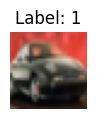

In [2]:
cifar_images = np.load("data/cifar10.1_v6_data.npy")
cifar_labels = np.load("data/cifar10.1_v6_labels.npy")

# Convert to channel-first tensor and scale to [0, 1]
if cifar_images.ndim == 4 and cifar_images.shape[-1] == 3:  # NHWC -> NCHW
    cifar_images = np.transpose(cifar_images, (0, 3, 1, 2))

cifar_images = torch.from_numpy(cifar_images).to(torch.get_default_dtype()) / 255.0
cifar_labels = torch.from_numpy(cifar_labels).long()

# Keep variable names used later in the notebook
cifar_test_ds = torch.utils.data.TensorDataset(cifar_images, cifar_labels)

cifar_loader = DataLoader(
    cifar_test_ds,
    batch_size=100,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"CIFAR10.1 OOD samples: {len(cifar_test_ds)}")

# Plot one example
img, label = cifar_test_ds[200]
plt.figure(figsize=(1, 1))
plt.imshow(img.permute(1, 2, 0).cpu().numpy())
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [3]:
from onnx2pytorch import ConvertModel

import json_to_pytorch

import attack

## Provable Bounds NN
### Large GeLU

In [54]:
# Import onnx model
onnx_model = onnx.load("../networks/cifar/best_model_bn_8_0.0001l1_no_pad.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [55]:
test_model_sampled = json_to_pytorch.json_to_pytorch("../results/gelu/cifar/best_model_bn_8_0.0001l1_247.json", double_precision=True, oob_nan=True)

In [56]:
reference_model

ConvertModel(
  (BatchNormalization_getitem): BatchNormWrapper(
    (bnu): BatchNormUnsafe(3, eps=9.999999960041972e-13, momentum=0.8999999761581421, affine=True, track_running_stats=True)
  )
  (Conv_conv2d): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu): GELU(approximate='none')
  (Conv_conv2d_1): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu_1): GELU(approximate='none')
  (Conv_conv2d_2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu_2): GELU(approximate='none')
  (Reshape_view): Reshape(shape=[  1 288])
  (Gemm_linear): Linear(in_features=288, out_features=256, bias=True)
  (Gelu_gelu_3): GELU(approximate='none')
  (Gemm_output): Linear(in_features=256, out_features=10, bias=True)
)

In [57]:
#adv = attack.Adversary(attacks_iter=2, attack_restarts=2, attack_epsilon=10.0/255.0)
#adv = attack.AffineAdversary(attacks_iter=2, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2)
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=15.0/255.0, noise_shape=(3, 32, 32), rotation_scale=True)

In [58]:
# Conv Net -> Later activation layers work better...
#adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_1", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_2", "reference_model", "input")
adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_2", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("2", "test_model", "input")

In [59]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [60]:
adv_examples = robust_eval_results_sampled["adv_examples"]

In [61]:
robust_eval_results_sampled["adv_examples"] = None
robust_eval_results_sampled

{'normal_loss_ref': 0.013027793352125097,
 'normal_loss_test': 0.011409228231627197,
 'adv_loss_ref': 0.07199036935077877,
 'adv_loss_test': 0.06399177299588107,
 'normal_acc_ref': 0.5925,
 'normal_acc_test': 0.619,
 'adv_acc_ref': 0.2115,
 'adv_acc_test': 0.2605,
 'normal_eq': 0.8075,
 'adv_eq': 0.8315,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.0,
 'total': 2000,
 'adv_examples': None}

### Small GeLU

In [62]:
# Import onnx model
onnx_model = onnx.load("../networks/cifar/best_model_bn_4_0.0001l1.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [63]:
test_model_sampled = json_to_pytorch.json_to_pytorch("../results/gelu/cifar/best_model_bn_4_0.0001l1_247.json", double_precision=True, oob_nan=True)

In [64]:
reference_model

ConvertModel(
  (BatchNormalization_/0/BatchNormalization_output_0): BatchNormWrapper(
    (bnu): BatchNormUnsafe(3, eps=9.999999960041972e-13, momentum=0.8999999761581421, affine=True, track_running_stats=True)
  )
  (Conv_/1/Conv_output_0): Conv2d(3, 4, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/2/Gelu_output_0): GELU(approximate='none')
  (Conv_/3/Conv_output_0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/4/Gelu_output_0): GELU(approximate='none')
  (Conv_/5/Conv_output_0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/6/Gelu_output_0): GELU(approximate='none')
  (Flatten_/7/Flatten_output_0): Flatten()
  (Gemm_/8/Gemm_output_0): Linear(in_features=144, out_features=256, bias=True)
  (Gelu_/9/Gelu_output_0): GELU(approximate='none')
  (Gemm_output): Linear(in_features=256, out_features=10, bias=True)
)

In [65]:
#adv = attack.Adversary(attacks_iter=2, attack_restarts=2, attack_epsilon=10.0/255.0)
#adv = attack.AffineAdversary(attacks_iter=2, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2)
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=15.0/255.0, noise_shape=(3, 32, 32), rotation_scale=True)

In [66]:
adv.loss_strategy = attack.InternalMaxLoss("Gelu_/6/Gelu_output_0", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("2", "test_model", "input")

In [67]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [68]:
adv_examples = robust_eval_results_sampled["adv_examples"]

In [69]:
robust_eval_results_sampled["adv_examples"] = None
robust_eval_results_sampled

{'normal_loss_ref': 0.015938328331915497,
 'normal_loss_test': 0.01332417193510698,
 'adv_loss_ref': 0.031024694857210138,
 'adv_loss_test': 0.02567685987417631,
 'normal_acc_ref': 0.483,
 'normal_acc_test': 0.553,
 'adv_acc_ref': 0.275,
 'adv_acc_test': 0.3155,
 'normal_eq': 0.8345,
 'adv_eq': 0.844,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.0,
 'total': 2000,
 'adv_examples': None}

## Sampling Based GeLU
### Large GeLU

In [42]:
# Import onnx model
onnx_model = onnx.load("../networks/cifar/best_model_bn_8_0.0001l1_no_pad.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [43]:
test_model_sampled = json_to_pytorch.json_to_pytorch("../results/gelu/cifar/best_model_bn_8_0.0001l1_247_sampling.json", double_precision=True, oob_nan=True)

In [44]:
reference_model

ConvertModel(
  (BatchNormalization_getitem): BatchNormWrapper(
    (bnu): BatchNormUnsafe(3, eps=9.999999960041972e-13, momentum=0.8999999761581421, affine=True, track_running_stats=True)
  )
  (Conv_conv2d): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu): GELU(approximate='none')
  (Conv_conv2d_1): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu_1): GELU(approximate='none')
  (Conv_conv2d_2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_gelu_2): GELU(approximate='none')
  (Reshape_view): Reshape(shape=[  1 288])
  (Gemm_linear): Linear(in_features=288, out_features=256, bias=True)
  (Gelu_gelu_3): GELU(approximate='none')
  (Gemm_output): Linear(in_features=256, out_features=10, bias=True)
)

In [45]:
test_model_sampled

Sequential(
  (0): FrozenBatchNorm()
  (1): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2))
  (2): ChebyshevPoly()
  (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (4): ChebyshevPoly()
  (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
  (6): ChebyshevPoly()
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=288, out_features=256, bias=True)
  (9): ChebyshevPoly()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [46]:
#adv = attack.Adversary(attacks_iter=2, attack_restarts=2, attack_epsilon=10.0/255.0)
#adv = attack.AffineAdversary(attacks_iter=2, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2)
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=15.0/255.0, noise_shape=(3, 32, 32), rotation_scale=True)

In [48]:
# Conv Net -> Later activation layers work better...
#adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_1", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_2", "reference_model", "input")
adv.loss_strategy = attack.InternalMaxLoss("Gelu_gelu_2", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("2", "test_model", "input")

In [49]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [50]:
adv_examples = robust_eval_results_sampled["adv_examples"]

In [51]:
robust_eval_results_sampled["adv_examples"] = None
robust_eval_results_sampled

{'normal_loss_ref': 0.013027793352125097,
 'normal_loss_test': 0.010942401360989605,
 'adv_loss_ref': 0.0702951084305912,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.5925,
 'normal_acc_test': 0.6455,
 'adv_acc_ref': 0.207,
 'adv_acc_test': 0.1395,
 'normal_eq': 0.8845,
 'adv_eq': 0.46,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.467,
 'total': 2000,
 'adv_examples': None}

tensor([ 1,  8,  9, 10, 11, 15, 17, 19, 23, 32, 35, 38, 39, 41, 48, 49, 50, 52,
        54, 55, 56, 57, 59, 60, 64, 66, 68, 70, 72, 73, 75, 81, 85, 89, 92, 93,
        95, 96])
tensor([ 0,  2,  7, 18, 19, 20, 24, 26, 29, 30, 31, 33, 34, 35, 37, 38, 41, 43,
        50, 53, 59, 60, 64, 66, 67, 70, 76, 79, 81, 82, 83, 84, 85, 88, 90, 91,
        92, 93, 98, 99])
tensor([ 1,  2,  3,  5,  6,  8, 11, 14, 16, 19, 20, 22, 25, 26, 28, 29, 31, 39,
        40, 43, 44, 47, 48, 51, 52, 57, 60, 62, 64, 70, 71, 72, 74, 75, 77, 78,
        79, 80, 81, 82, 85, 87, 89, 90, 94])
tensor([ 1,  4,  6,  7,  8, 14, 17, 18, 21, 22, 23, 24, 25, 28, 30, 31, 32, 36,
        38, 39, 40, 41, 42, 45, 52, 53, 55, 56, 58, 61, 62, 63, 65, 68, 74, 75,
        77, 78, 79, 81, 82, 84, 89, 92, 94])
tensor([ 5,  8, 10, 11, 12, 14, 18, 20, 25, 26, 28, 31, 34, 35, 36, 37, 42, 43,
        45, 47, 48, 49, 50, 53, 58, 61, 63, 65, 66, 68, 69, 72, 73, 75, 76, 77,
        79, 80, 81, 82, 83, 85, 87, 88, 93, 94, 98])
tensor([ 1,  2,

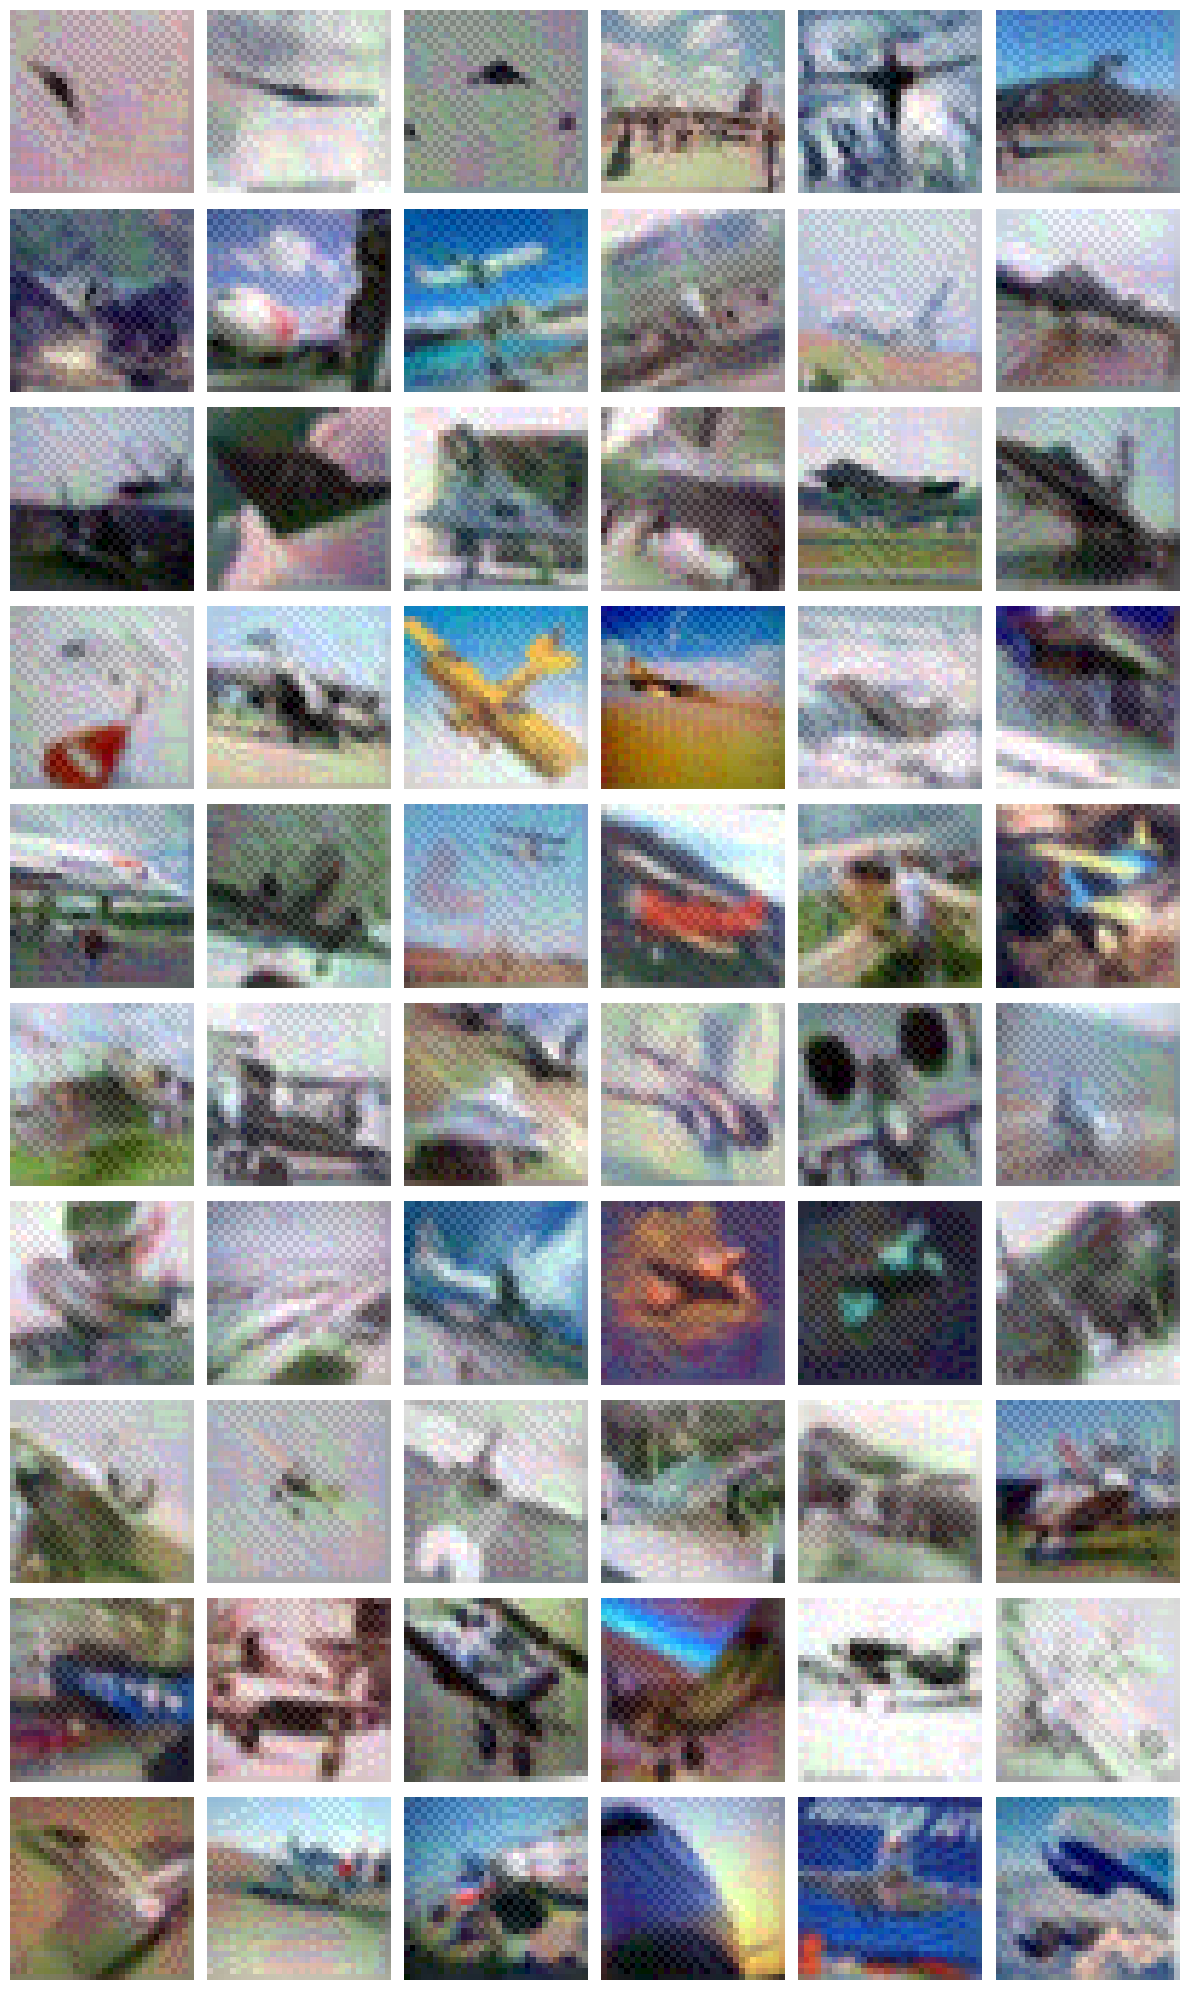

In [52]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            #(ref.argmax(1) != test.argmax(1)) |
            torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        print(idxs)
        for idx in idxs:
            changed_samples.append(x[idx].permute(1, 2, 0).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 10)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        img_show = np.clip(changed_samples[i], 0, 1)
        axes[i].imshow(img_show)
        #axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [53]:
# Save figure
fig.savefig("figures/cifar_large_sampled_nan.png", dpi=300)

### Small GeLU

In [15]:
# Import onnx model
onnx_model = onnx.load("../networks/cifar/best_model_bn_4_0.0001l1.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [16]:
test_model_sampled = json_to_pytorch.json_to_pytorch("../results/gelu/cifar/best_model_bn_4_0.0001l1_247_sampling.json", double_precision=True, oob_nan=True)

In [17]:
reference_model

ConvertModel(
  (BatchNormalization_/0/BatchNormalization_output_0): BatchNormWrapper(
    (bnu): BatchNormUnsafe(3, eps=9.999999960041972e-13, momentum=0.8999999761581421, affine=True, track_running_stats=True)
  )
  (Conv_/1/Conv_output_0): Conv2d(3, 4, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/2/Gelu_output_0): GELU(approximate='none')
  (Conv_/3/Conv_output_0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/4/Gelu_output_0): GELU(approximate='none')
  (Conv_/5/Conv_output_0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (Gelu_/6/Gelu_output_0): GELU(approximate='none')
  (Flatten_/7/Flatten_output_0): Flatten()
  (Gemm_/8/Gemm_output_0): Linear(in_features=144, out_features=256, bias=True)
  (Gelu_/9/Gelu_output_0): GELU(approximate='none')
  (Gemm_output): Linear(in_features=256, out_features=10, bias=True)
)

In [18]:
test_model_sampled

Sequential(
  (0): FrozenBatchNorm()
  (1): Conv2d(3, 4, kernel_size=(3, 3), stride=(2, 2))
  (2): ChebyshevPoly()
  (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2))
  (4): ChebyshevPoly()
  (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2))
  (6): ChebyshevPoly()
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=144, out_features=256, bias=True)
  (9): ChebyshevPoly()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [35]:
#adv = attack.Adversary(attacks_iter=2, attack_restarts=2, attack_epsilon=10.0/255.0)
#adv = attack.AffineAdversary(attacks_iter=2, attack_restarts=2, epsilon_rot=0.4, epsilon_tx=0.2, epsilon_ty=0.2)
adv = attack.NoisyAffineAdversary(attacks_iter=16, attack_restarts=2, epsilon_rot=0.3, epsilon_tx=0.0, epsilon_ty=0.0, epsilon_noise=15.0/255.0, noise_shape=(3, 32, 32), rotation_scale=True)

In [36]:
adv.loss_strategy = attack.InternalMaxLoss("Gelu_/6/Gelu_output_0", "reference_model", "input")
#adv.loss_strategy = attack.InternalMaxLoss("2", "test_model", "input")

In [37]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, cifar_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [38]:
adv_examples = robust_eval_results_sampled["adv_examples"]

In [39]:
robust_eval_results_sampled["adv_examples"] = None
robust_eval_results_sampled

{'normal_loss_ref': 0.01589169363377772,
 'normal_loss_test': 0.01333400536990001,
 'adv_loss_ref': 0.03006966952553176,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.484,
 'normal_acc_test': 0.5475,
 'adv_acc_ref': 0.273,
 'adv_acc_test': 0.322,
 'normal_eq': 0.8245,
 'adv_eq': 0.8535,
 'normal_nans_ref': 0.0,
 'normal_nans_test': 0.0,
 'adv_nans_ref': 0.0,
 'adv_nans_test': 0.001,
 'total': 2000,
 'adv_examples': None}

tensor([], dtype=torch.int64)
tensor([47])
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([], dtype=torch.int64)
tensor([75])
Found 2 changed samples. Displaying...


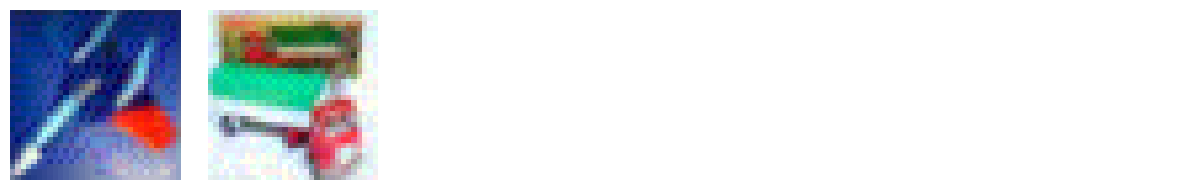

In [40]:
# Plot all adversarial examples where outcome actually changed
# (different classification between models or NaN in either output)

changed_samples = []
changed_titles = []

with torch.no_grad():
    for adv_ex, orig_pred, adv_pred in adv_examples:
        x = adv_ex.to("cpu")
        ref = reference_model(x)
        test = test_model_sampled(x)

        changed = (
            #(ref.argmax(1) != test.argmax(1)) |
            torch.isnan(ref).any(dim=1)
            | torch.isnan(test).any(dim=1)
        )

        idxs = changed.nonzero(as_tuple=True)[0]
        print(idxs)
        for idx in idxs:
            changed_samples.append(x[idx].permute(1, 2, 0).cpu().numpy())
            ref_pred = ref[idx].argmax().item()
            test_pred = test[idx]
            if torch.isnan(test_pred).any():
                changed_titles.append(f"Orig: {ref_pred} -> Adv: NaN")
            else:
                changed_titles.append(f"Orig: {ref_pred} -> Adv: {test_pred.argmax().item()}")

n = len(changed_samples)
if n == 0:
    print("No changed samples found.")
else:
    print("Found {} changed samples. Displaying...".format(n))
    ncols = 6
    nrows = int(np.ceil(n / ncols))
    nrows = min(nrows, 10)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i in range(min(n, ncols*nrows)):
        img_show = np.clip(changed_samples[i], 0, 1)
        axes[i].imshow(img_show)
        #axes[i].set_title(changed_titles[i], fontsize=8)
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [41]:
# Save figure
fig.savefig("figures/cifar_small_sampled_nan.png", dpi=300)